# Bottleneck & Latent Space Optimization Analysis

In this notebook, we'll focus specifically on the bottleneck architecture optimization:

```
latent-space → Reshape(Nlat-space, 1, 1, 1) → Upsampling3D(Nlat-space, Nx, Ny, Nz) 
→ Conv3D(Nlat-space, Nlat-space, (Nx, Ny, Nz), groups = Nlat-space) 
→ Conv3D(Nlat-space, Nchan, 1) → Activation
```

This approach associates each latent space variable with a "basis image" and combines them
by weighing them by the latent space intensity, significantly reducing parameter count.

## Setup & Imports

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
from collections import OrderedDict
import matplotlib.pyplot as plt
from pathlib import Path
import os
from tqdm.auto import tqdm


# Runtime reload
import importlib
import models.autoencoder.selected_model
importlib.reload(models.autoencoder.selected_model)


from data.data_ingestion import collect_files, generate_dataframe
from data.dataloader import create_dataloaders
from models.autoencoder.selected_model import (
    BaseEncoder,
    BaseDecoder,
    BottleneckEncoder,
    BottleneckBasisDecoder,
    BottleneckHybridDecoder,
    BottleneckDeconvDecoder,
    BottleneckAE,
    SpatialAE,
)
from models.autoencoder.training import train_autoencoder
from models.autoencoder.config import TrainingConfig


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def save_model(m, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    torch.save(m.state_dict(), path)

def count_trainable(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


Device: cuda


## Quick Smoke Test

In [17]:
# Quick function to instantiate each pipeline, run a forward with dummy input and print stats
def smoke_test_pipeline(batch=1, input_shape=(1,64,128,128), latent_dim=128, bottleneck_shape=(1,1,1)):
    B, C, D, H, W = batch, input_shape[0], input_shape[1], input_shape[2], input_shape[3]
    dummy = torch.randn(B, C, D, H, W).to(device)
    print("Dummy input:", dummy.shape)

    # 1) Vanilla AE (spatial latent)
    enc_v = BaseEncoder(initial_filters=4).to(device)
    dec_v = BaseDecoder(latent_dim=128).to(device)
    ae_v = SpatialAE(enc_v, dec_v).to(device)
    with torch.no_grad():
        out_v = ae_v(dummy)
    print("Vanilla AE out:", out_v.shape, "params:", count_parameters(ae_v))

    # 2) Bottleneck Basis
    enc_b = BottleneckEncoder(initial_filters=4, latent_dim=latent_dim, bottleneck_shape=bottleneck_shape).to(device)
    dec_basis = BottleneckBasisDecoder(latent_dim=latent_dim, initial_shape=(4,8,8)).to(device)
    ae_basis = BottleneckAE(enc_b, dec_basis).to(device)
    with torch.no_grad():
        out_basis = ae_basis(dummy)
    print("Bottleneck Basis out:", out_basis.shape, "params:", count_parameters(ae_basis))

    # 3) Bottleneck Deconv
    enc_b2 = BottleneckEncoder(initial_filters=4, latent_dim=latent_dim, bottleneck_shape=bottleneck_shape).to(device)
    dec_deconv = BottleneckDeconvDecoder(latent_dim=latent_dim, initial_shape=(4,8,8)).to(device)
    ae_deconv = BottleneckAE(enc_b2, dec_deconv).to(device)
    with torch.no_grad():
        out_deconv = ae_deconv(dummy)
    print("Bottleneck Deconv out:", out_deconv.shape, "params:", count_parameters(ae_deconv))

    # 4) Bottleneck Hybrid
    enc_b3 = BottleneckEncoder(initial_filters=4, latent_dim=latent_dim, bottleneck_shape=bottleneck_shape).to(device)
    dec_hy = BottleneckHybridDecoder(latent_dim=latent_dim, initial_shape=(4,8,8)).to(device)
    ae_hy = BottleneckAE(enc_b3, dec_hy).to(device)
    with torch.no_grad():
        out_hy = ae_hy(dummy)
    print("Bottleneck Hybrid out:", out_hy.shape, "params:", count_parameters(ae_hy))

In [18]:
# Run a smoke test
smoke_test_pipeline(batch=1, input_shape=(1,64,128,128), latent_dim=128, bottleneck_shape=(1,1,1))

Dummy input: torch.Size([1, 1, 64, 128, 128])
Vanilla AE out: torch.Size([1, 1, 64, 128, 128]) params: 955673


d:\UNIMIB\Thesis\refactoried_project\venv\Lib\site-packages\torch\nn\modules\conv.py:712: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\Convolution.cpp:1028.)
  return F.conv3d(


Bottleneck Basis out: torch.Size([1, 1, 64, 128, 128]) params: 778065
Bottleneck Deconv out: torch.Size([1, 1, 64, 128, 128]) params: 2834129
Bottleneck Hybrid out: torch.Size([1, 1, 64, 128, 128]) params: 781585


In [19]:
def extended_test_suite(
    batch=1,
    input_shape=(1,64,128,128),
    latent_dim_list=[32,64,128],
    bottleneck_shapes=[(1,1,1),(2,4,4)],
    group_settings=['full','partial','none']
):
    results = []
    for latent_dim in latent_dim_list:
        for bshape in bottleneck_shapes:
            for gset in group_settings:
                print(f"\n🧪 latent_dim={latent_dim}  bottleneck_shape={bshape}  groups={gset}")

                # base encoder + basis decoder with group variants
                enc = BottleneckEncoder(initial_filters=4, latent_dim=latent_dim, bottleneck_shape=bshape).to(device)
                if gset == 'full':
                    groups = latent_dim
                elif gset == 'partial':
                    groups = max(1, latent_dim//4)
                else:
                    groups = 1

                # modify grouped_conv groups dynamically
                dec_basis = BottleneckBasisDecoder(latent_dim=latent_dim, initial_shape=(4,8,8)).to(device)
                dec_basis.grouped_conv = nn.Conv3d(latent_dim, latent_dim, kernel_size=(4,8,8), groups=groups).to(device)

                ae_basis = BottleneckAE(enc, dec_basis).to(device)
                dummy = torch.randn(batch, *input_shape).to(device)
                with torch.no_grad():
                    out = ae_basis(dummy)
                results.append({
                    'variant': 'basis',
                    'latent_dim': latent_dim,
                    'bottleneck_shape': bshape,
                    'groups': groups,
                    'params': count_parameters(ae_basis),
                    'output_shape': tuple(out.shape)
                })

                # deconv variant (no groups)
                enc2 = BottleneckEncoder(initial_filters=4, latent_dim=latent_dim, bottleneck_shape=bshape).to(device)
                dec_deconv = BottleneckDeconvDecoder(latent_dim=latent_dim, initial_shape=(4,8,8)).to(device)
                ae_deconv = BottleneckAE(enc2, dec_deconv).to(device)
                with torch.no_grad():
                    out2 = ae_deconv(dummy)
                results.append({
                    'variant': 'deconv',
                    'latent_dim': latent_dim,
                    'bottleneck_shape': bshape,
                    'groups': 1,
                    'params': count_parameters(ae_deconv),
                    'output_shape': tuple(out2.shape)
                })

                # hybrid variant
                enc3 = BottleneckEncoder(initial_filters=4, latent_dim=latent_dim, bottleneck_shape=bshape).to(device)
                dec_hy = BottleneckHybridDecoder(latent_dim=latent_dim, initial_shape=(4,8,8)).to(device)
                ae_hy = BottleneckAE(enc3, dec_hy).to(device)
                with torch.no_grad():
                    out3 = ae_hy(dummy)
                results.append({
                    'variant': 'hybrid',
                    'latent_dim': latent_dim,
                    'bottleneck_shape': bshape,
                    'groups': 'N/A',
                    'params': count_parameters(ae_hy),
                    'output_shape': tuple(out3.shape)
                })
    df = pd.DataFrame(results)
    display(df)
    return df



In [20]:
# Run the extended test
df_results = extended_test_suite(batch=1, input_shape=(1,32,64,64), latent_dim_list=[32,64], bottleneck_shapes=[(1,1,1),(2,4,4)], group_settings=['full','partial','none'])



🧪 latent_dim=32  bottleneck_shape=(1, 1, 1)  groups=full

🧪 latent_dim=32  bottleneck_shape=(1, 1, 1)  groups=partial

🧪 latent_dim=32  bottleneck_shape=(1, 1, 1)  groups=none

🧪 latent_dim=32  bottleneck_shape=(2, 4, 4)  groups=full

🧪 latent_dim=32  bottleneck_shape=(2, 4, 4)  groups=partial

🧪 latent_dim=32  bottleneck_shape=(2, 4, 4)  groups=none

🧪 latent_dim=64  bottleneck_shape=(1, 1, 1)  groups=full

🧪 latent_dim=64  bottleneck_shape=(1, 1, 1)  groups=partial

🧪 latent_dim=64  bottleneck_shape=(1, 1, 1)  groups=none

🧪 latent_dim=64  bottleneck_shape=(2, 4, 4)  groups=full

🧪 latent_dim=64  bottleneck_shape=(2, 4, 4)  groups=partial

🧪 latent_dim=64  bottleneck_shape=(2, 4, 4)  groups=none


,variant,latent_dim,bottleneck_shape,groups,params,output_shape
0,basis,32,"(1, 1, 1)",32,751377,"(1, 1, 64, 128, 128)"
1,deconv,32,"(1, 1, 1)",1,1265393,"(1, 1, 64, 128, 128)"
2,hybrid,32,"(1, 1, 1)",N/A,776881,"(1, 1, 64, 128, 128)"
3,basis,32,"(1, 1, 1)",8,775953,"(1, 1, 64, 128, 128)"
4,deconv,32,"(1, 1, 1)",1,1265393,"(1, 1, 64, 128, 128)"
5,hybrid,32,"(1, 1, 1)",N/A,776881,"(1, 1, 64, 128, 128)"
6,basis,32,"(1, 1, 1)",1,1005329,"(1, 1, 64, 128, 128)"
7,deconv,32,"(1, 1, 1)",1,1265393,"(1, 1, 64, 128, 128)"
8,hybrid,32,"(1, 1, 1)",N/A,776881,"(1, 1, 64, 128, 128)"
9,basis,32,"(2, 4, 4)",32,751377,"(1, 1, 64, 128, 128)"


## Data setup

In [7]:
root_dir = Path(".")
images_dir = root_dir / "data" / "Images"
mask_path = root_dir / "data" / "masks" / "rmask_ICV.nii"

In [10]:
# Configuration
data_dir = "data/Images"
mask_path = "data/masks/rmask_ICV.nii"
batch_size = 4
output_dir = "output/Experiments/NotebookBottelneck"

# Create output directory
os.makedirs(output_dir, exist_ok=True)

# Prepare data
print("Collecting files...")
included_files, excluded_files = collect_files(data_dir)
print(f"Found {len(included_files)} valid files, excluded {len(excluded_files)} files")

# Generate dataframe
print("Generating dataframe...")
df = generate_dataframe(included_files)
display(df.head())

# Create dataloaders
print("Creating dataloaders...")
train_loader, val_loader = create_dataloaders(
    df, batch_size=batch_size, train_split=0.8, 
    on_demand=True, mask_path=mask_path
)

print(f"Data preparation complete. Train: {len(train_loader.dataset)}, Val: {len(val_loader.dataset)}")

Found 2976 valid files, excluded 893 files
Generating dataframe...


,file_path,label
0,data/Images/PPMI_Images_Cont/100004/Reconstruc...,Control
1,data/Images/PPMI_Images_Cont/100890/Reconstruc...,Control
2,data/Images/PPMI_Images_Cont/100956/Reconstruc...,Control
3,data/Images/PPMI_Images_Cont/101039/Reconstruc...,Control
4,data/Images/PPMI_Images_Cont/101195/Reconstruc...,Control


Creating dataloaders...

Training set distribution:
label
PD         2035
Control     235
SWEDD       110
Name: count, dtype: int64

Validation set distribution:
label
PD         510
Control     59
SWEDD       27
Name: count, dtype: int64
Using on-demand data loading strategy (lighter on memory but slower)
✅ Brain mask loaded successfully
✅ All 2380 file paths are valid
✅ Brain mask loaded successfully
✅ All 596 file paths are valid
Data preparation complete. Train: 2380, Val: 596


## Model Setup

In [11]:
target_shape = (64, 128, 128)

def build_model(variant, latent_dim=128, bottleneck_shape=(1,1,1), basis_groups="partial"):
    if variant == "vanilla":
        model = SpatialAE(
            BaseEncoder(initial_filters=4),
            BaseDecoder(latent_dim= latent_dim),
        )
    elif variant == "basis":
        model = BottleneckAE(
            BottleneckEncoder(initial_filters=4, latent_dim=latent_dim, bottleneck_shape=bottleneck_shape),
            BottleneckBasisDecoder(latent_dim=latent_dim, initial_shape=bottleneck_shape,
                                   target_shape=target_shape, groups=basis_groups),
        )
    elif variant == "deconv":
        model = BottleneckAE(
            BottleneckEncoder(initial_filters=4, latent_dim=latent_dim, bottleneck_shape=bottleneck_shape),
            BottleneckDeconvDecoder(latent_dim=latent_dim, initial_shape=bottleneck_shape,
                                    target_shape=target_shape),
        )
    elif variant == "hybrid":
        model = BottleneckAE(
            BottleneckEncoder(initial_filters=4, latent_dim=latent_dim, bottleneck_shape=bottleneck_shape),
            BottleneckHybridDecoder(latent_dim=latent_dim, initial_shape=bottleneck_shape,
                                    target_shape=target_shape),
        )
    else:
        raise ValueError(f"Unknown variant {variant}")
    return model.to(device)

In [13]:
def create_training_config(model_name, epochs=10):
    """Create a training configuration for a model"""
    config = TrainingConfig()
    config.epochs = epochs
    config.model_name = model_name
    config.checkpoint_dir = os.path.join(output_dir, model_name)
    config.early_stopping_patience = 5
    config.save_interval = 5
    config.learning_rate = 1e-4
    config.use_mixed_precision = True  # Use mixed precision for memory efficiency
    return config

In [15]:
settings = [
    ("vanilla", 128, (4,8,8), "full"),
    ("basis",   128, (1,1,1), "partial"),
    ("deconv",  128, (1,1,1), "partial"),
    ("hybrid",  128, (1,1,1), "partial"),
]

histories = {}

# Set number of epochs
num_epochs = 140  # Adjust as needed


=== Training vanilla (latent_dim=128, bottleneck_shape=(4, 8, 8), groups=full) ===

TRAINING CONFIGURATION
Model: autoencoder with latent dim 256
Batch size: 4 × 4 steps = 16 effective
Learning rate: 0.0001
Mixed precision: Enabled
Epochs: 100 with patience 10
Dataloader workers: 2
Checkpoints saved to: checkpoints

DEBUG: CheckpointHandler - Attempting to load checkpoint from output/Experiments/NotebookBottelneck/vanilla_lat128/vanilla_lat128_checkpoint.pth
No checkpoint found at output/Experiments/NotebookBottelneck/vanilla_lat128/vanilla_lat128_checkpoint.pth
DEBUG: Starting training loop


Progress [E1/140|Train]:   0%|                                                                | 0/83300 [00:00<?, ?it/s]

DEBUG: Starting epoch 1/140


Progress [E2/140|Train]:   1%|▎                                                   | 595/83300 [02:52<4:52:43,  4.71it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 0
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneck/vanilla_lat128/vanilla_lat128_checkpoint.pth
Saved best model to output/Experiments/NotebookBottelneck/vanilla_lat128/vanilla_lat128_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottelneck/vanilla_lat128/vanilla_lat128_metadata.json
Epoch 1/140 | Train: 0.173133 | Val: 0.111341 | LR: 0.00010000 | ETA: 398.51m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 11.63 MB
Cached: 50.00 MB
CPU Memory Usage: 1884.48 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.111341, Best loss: inf
Validation loss improved by inf
DEBUG: EarlyStopping - Loss improved, counter reset to 0
DEBUG: Completed epoch 1/140, continuing to next epoch
DEBUG: Starting epoch 2/140


...

Progress [E44/140|Train]:  31%|███████████████▋                                   | 25585/83300 [28:12<49:00, 19.63it/s]

Epoch 43/140 | Train: 0.004118 | Val: 0.004355 | LR: 0.00010000 | ETA: 63.63m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 11.63 MB
Cached: 50.00 MB
CPU Memory Usage: 1902.14 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.004355, Best loss: 0.004322
Early stopping counter: 5/5
DEBUG: EarlyStopping - No improvement, counter increased to 5/5
Early stopping triggered. Best epoch was 37.
DEBUG: EarlyStopping - Patience exceeded, early_stop set to True
DEBUG: Completed epoch 43/140, continuing to next epoch
DEBUG: Starting epoch 44/140


Progress [E44/140|Val]:  31%|████████████████                                   | 26180/83300 [28:48<1:02:51, 15.14it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 43
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneck/vanilla_lat128/vanilla_lat128_checkpoint.pth
Saved best model to output/Experiments/NotebookBottelneck/vanilla_lat128/vanilla_lat128_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottelneck/vanilla_lat128/vanilla_lat128_metadata.json
Epoch 44/140 | Train: 0.004116 | Val: 0.004224 | LR: 0.00010000 | ETA: 62.87m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 11.63 MB
Cached: 50.00 MB
CPU Memory Usage: 1902.14 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.004224, Best loss: 0.004322
Validation loss improved by 0.000098
DEBUG: EarlyStopping - Loss improved, counter reset to 0

Early stopping triggered!
DEBUG: Entering finally block
DEBUG: About to plot training history


DEBUG: Saving plot to output/Experiments/NotebookBottelneck/vanilla_lat128/vanilla_lat128_training_history.png


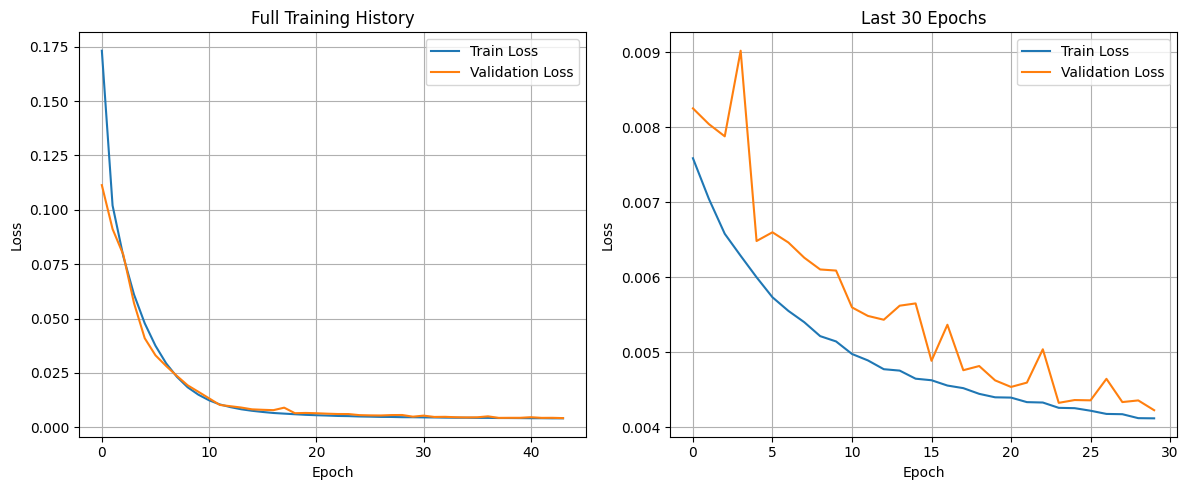

DEBUG: Plot saved and displayed successfully

Training completed in 28.82 minutes
Best validation loss: 0.004224

=== Training basis (latent_dim=128, bottleneck_shape=(1, 1, 1), groups=partial) ===

TRAINING CONFIGURATION
Model: autoencoder with latent dim 256
Batch size: 4 × 4 steps = 16 effective
Learning rate: 0.0001
Mixed precision: Enabled
Epochs: 100 with patience 10
Dataloader workers: 2
Checkpoints saved to: checkpoints

DEBUG: CheckpointHandler - Attempting to load checkpoint from output/Experiments/NotebookBottelneck/basis_lat128/basis_lat128_checkpoint.pth
No checkpoint found at output/Experiments/NotebookBottelneck/basis_lat128/basis_lat128_checkpoint.pth
DEBUG: Starting training loop


Progress [E1/140|Train]:   0%|                                                                | 0/83300 [00:00<?, ?it/s]

DEBUG: Starting epoch 1/140


Progress [E2/140|Train]:   1%|▍                                                     | 595/83300 [00:31<58:23, 23.60it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 0
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneck/basis_lat128/basis_lat128_checkpoint.pth
Saved best model to output/Experiments/NotebookBottelneck/basis_lat128/basis_lat128_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottelneck/basis_lat128/basis_lat128_metadata.json
Epoch 1/140 | Train: 0.159205 | Val: 0.137811 | LR: 0.00010000 | ETA: 73.33m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 20.87 MB
Cached: 74.00 MB
CPU Memory Usage: 1937.06 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.137811, Best loss: inf
Validation loss improved by inf
DEBUG: EarlyStopping - Loss improved, counter reset to 0
DEBUG: Completed epoch 1/140, continuing to next epoch
DEBUG: Starting epoch 2/140


...

Epoch 138/140 | Train: 0.117249 | Val: 0.196027 | LR: 0.00000100 | ETA: 1.05m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 20.87 MB
Cached: 74.00 MB
CPU Memory Usage: 1998.33 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.196027, Best loss: 0.127884
Early stopping counter: 134/5
DEBUG: EarlyStopping - No improvement, counter increased to 134/5
Early stopping triggered. Best epoch was 3.
DEBUG: EarlyStopping - Patience exceeded, early_stop set to True
DEBUG: Completed epoch 138/140, continuing to next epoch
DEBUG: Starting epoch 139/140


Progress [E140/140|Train]:  99%|███████████████████████████████████████████████▋| 82705/83300 [1:12:44<00:25, 23.26it/s]

Epoch 139/140 | Train: 0.117231 | Val: 0.158375 | LR: 0.00000100 | ETA: 0.52m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 20.87 MB
Cached: 74.00 MB
CPU Memory Usage: 1998.33 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.158375, Best loss: 0.127884
Early stopping counter: 135/5
DEBUG: EarlyStopping - No improvement, counter increased to 135/5
Early stopping triggered. Best epoch was 3.
DEBUG: EarlyStopping - Patience exceeded, early_stop set to True
DEBUG: Completed epoch 139/140, continuing to next epoch
DEBUG: Starting epoch 140/140


Progress [E140/140|Val]: 100%|██████████████████████████████████████████████████| 83300/83300 [1:13:15<00:00, 18.95it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 139
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneck/basis_lat128/basis_lat128_checkpoint.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottelneck/basis_lat128/basis_lat128_metadata.json
Epoch 140/140 | Train: 0.117251 | Val: 0.171489 | LR: 0.00000100 | ETA: 0.00m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 20.87 MB
Cached: 74.00 MB
CPU Memory Usage: 1998.33 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.171489, Best loss: 0.127884
Early stopping counter: 136/5
DEBUG: EarlyStopping - No improvement, counter increased to 136/5
Early stopping triggered. Best epoch was 3.
DEBUG: EarlyStopping - Patience exceeded, early_stop set to True
DEBUG: Completed epoch 140/140, continuing to next epoch
DEBUG: Entering finally block
DEBUG: About to plot training histor

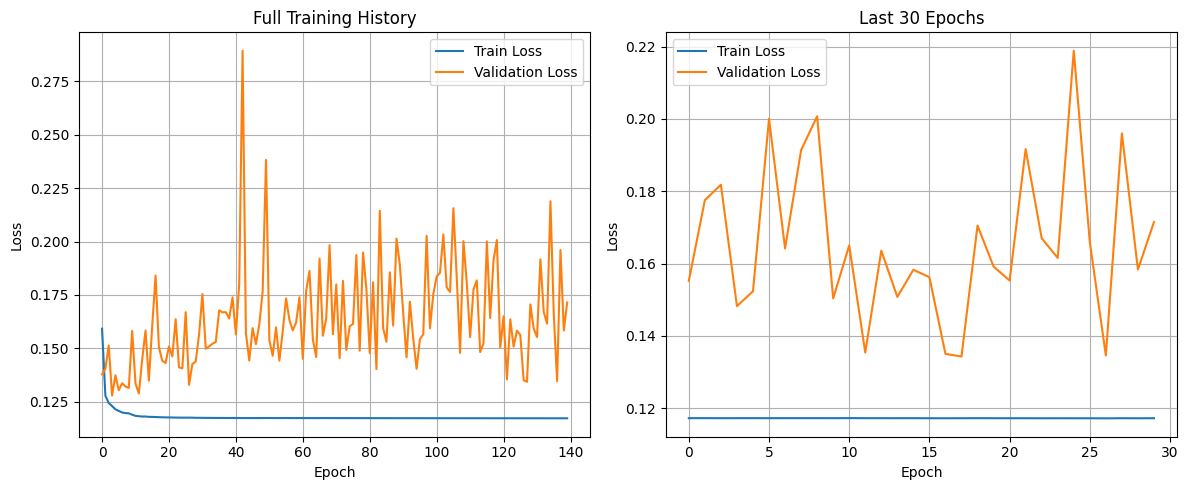

DEBUG: Plot saved and displayed successfully

Training completed in 73.27 minutes
Best validation loss: 0.127884

=== Training deconv (latent_dim=128, bottleneck_shape=(1, 1, 1), groups=partial) ===

TRAINING CONFIGURATION
Model: autoencoder with latent dim 256
Batch size: 4 × 4 steps = 16 effective
Learning rate: 0.0001
Mixed precision: Enabled
Epochs: 100 with patience 10
Dataloader workers: 2
Checkpoints saved to: checkpoints

DEBUG: CheckpointHandler - Attempting to load checkpoint from output/Experiments/NotebookBottelneck/deconv_lat128/deconv_lat128_checkpoint.pth
No checkpoint found at output/Experiments/NotebookBottelneck/deconv_lat128/deconv_lat128_checkpoint.pth
DEBUG: Starting training loop


Progress [E1/140|Train]:   0%|                                                                | 0/83300 [00:00<?, ?it/s]

DEBUG: Starting epoch 1/140


Progress [E1/140|Val]:   1%|▍                                                       | 595/83300 [00:25<57:53, 23.81it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 0


...

Progress [E23/140|Train]:  16%|████████                                           | 13090/83300 [11:16<48:59, 23.88it/s]

Epoch 22/140 | Train: 0.117046 | Val: 0.117511 | LR: 0.00010000 | ETA: 60.48m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 29.47 MB
Cached: 102.00 MB
CPU Memory Usage: 2010.97 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.117511, Best loss: 0.117097
Early stopping counter: 5/5
DEBUG: EarlyStopping - No improvement, counter increased to 5/5
Early stopping triggered. Best epoch was 16.
DEBUG: EarlyStopping - Patience exceeded, early_stop set to True
DEBUG: Completed epoch 22/140, continuing to next epoch
DEBUG: Starting epoch 23/140


Progress [E23/140|Val]:  16%|████████▋                                            | 13685/83300 [11:47<59:57, 19.35it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 22
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneck/deconv_lat128/deconv_lat128_checkpoint.pth
Saved best model to output/Experiments/NotebookBottelneck/deconv_lat128/deconv_lat128_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottelneck/deconv_lat128/deconv_lat128_metadata.json
Epoch 23/140 | Train: 0.117052 | Val: 0.116932 | LR: 0.00010000 | ETA: 59.96m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 29.47 MB
Cached: 102.00 MB
CPU Memory Usage: 2010.98 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.116932, Best loss: 0.117097
Validation loss improved by 0.000165
DEBUG: EarlyStopping - Loss improved, counter reset to 0

Early stopping triggered!
DEBUG: Entering finally block
DEBUG: About to plot training history


DEBUG: Saving plot to output/Experiments/NotebookBottelneck/deconv_lat128/deconv_lat128_training_history.png


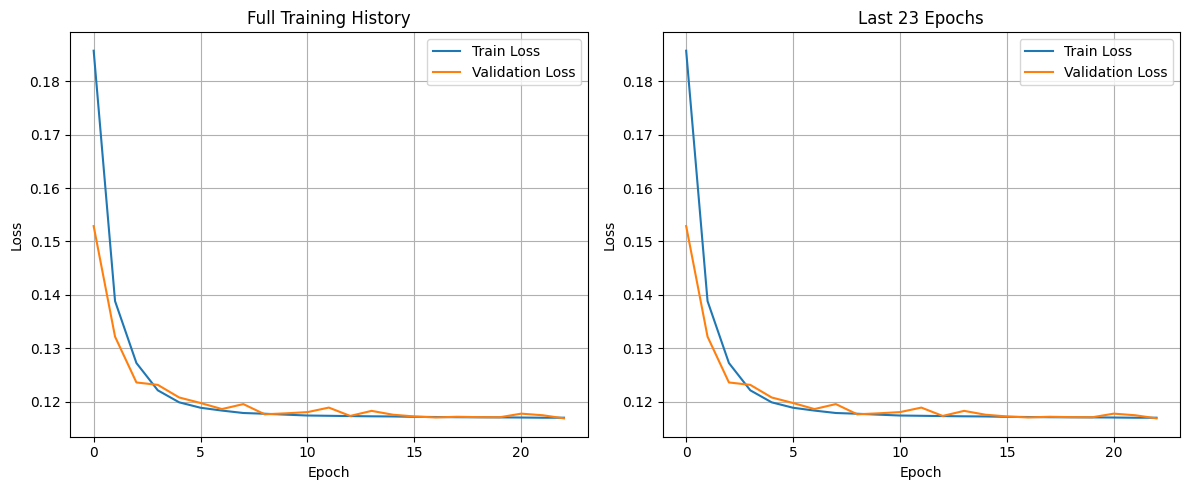

DEBUG: Plot saved and displayed successfully

Training completed in 11.79 minutes
Best validation loss: 0.116932

=== Training hybrid (latent_dim=128, bottleneck_shape=(1, 1, 1), groups=partial) ===

TRAINING CONFIGURATION
Model: autoencoder with latent dim 256
Batch size: 4 × 4 steps = 16 effective
Learning rate: 0.0001
Mixed precision: Enabled
Epochs: 100 with patience 10
Dataloader workers: 2
Checkpoints saved to: checkpoints

DEBUG: CheckpointHandler - Attempting to load checkpoint from output/Experiments/NotebookBottelneck/hybrid_lat128/hybrid_lat128_checkpoint.pth
No checkpoint found at output/Experiments/NotebookBottelneck/hybrid_lat128/hybrid_lat128_checkpoint.pth
DEBUG: Starting training loop


Progress [E1/140|Train]:   0%|                                                                | 0/83300 [00:00<?, ?it/s]

DEBUG: Starting epoch 1/140


Progress [E2/140|Train]:   1%|▍                                                     | 595/83300 [00:28<53:34, 25.73it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 0
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneck/hybrid_lat128/hybrid_lat128_checkpoint.pth
Saved best model to output/Experiments/NotebookBottelneck/hybrid_lat128/hybrid_lat128_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottelneck/hybrid_lat128/hybrid_lat128_metadata.json
Epoch 1/140 | Train: 0.294798 | Val: 0.218057 | LR: 0.00010000 | ETA: 66.07m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 38.48 MB
Cached: 134.00 MB
CPU Memory Usage: 2020.70 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.218057, Best loss: inf
Validation loss improved by inf
DEBUG: EarlyStopping - Loss improved, counter reset to 0
DEBUG: Completed epoch 1/140, continuing to next epoch
DEBUG: Starting epoch 2/140


...

Progress [E140/140|Train]:  99%|███████████████████████████████████████████████▋| 82705/83300 [1:05:58<00:23, 25.14it/s]

Epoch 139/140 | Train: 0.011388 | Val: 0.011494 | LR: 0.00010000 | ETA: 0.47m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 38.48 MB
Cached: 134.00 MB
CPU Memory Usage: 2027.67 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.011494, Best loss: 0.011367
Early stopping counter: 1/5
DEBUG: EarlyStopping - No improvement, counter increased to 1/5
DEBUG: Completed epoch 139/140, continuing to next epoch
DEBUG: Starting epoch 140/140


Progress [E140/140|Val]: 100%|██████████████████████████████████████████████████| 83300/83300 [1:06:27<00:00, 20.89it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 139
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneck/hybrid_lat128/hybrid_lat128_checkpoint.pth
Saved best model to output/Experiments/NotebookBottelneck/hybrid_lat128/hybrid_lat128_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottelneck/hybrid_lat128/hybrid_lat128_metadata.json
Epoch 140/140 | Train: 0.011523 | Val: 0.011364 | LR: 0.00010000 | ETA: 0.00m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 38.48 MB
Cached: 134.00 MB
CPU Memory Usage: 2027.68 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.011364, Best loss: 0.011367
Validation loss improved by 0.000002
DEBUG: EarlyStopping - Loss improved, counter reset to 0
DEBUG: Completed epoch 140/140, continuing to next epoch
DEBUG: Entering finally block
DEBUG: About to plot training history


DEBUG: Saving plot to output/Experiments/NotebookBottelneck/hybrid_lat128/hybrid_lat128_training_history.png


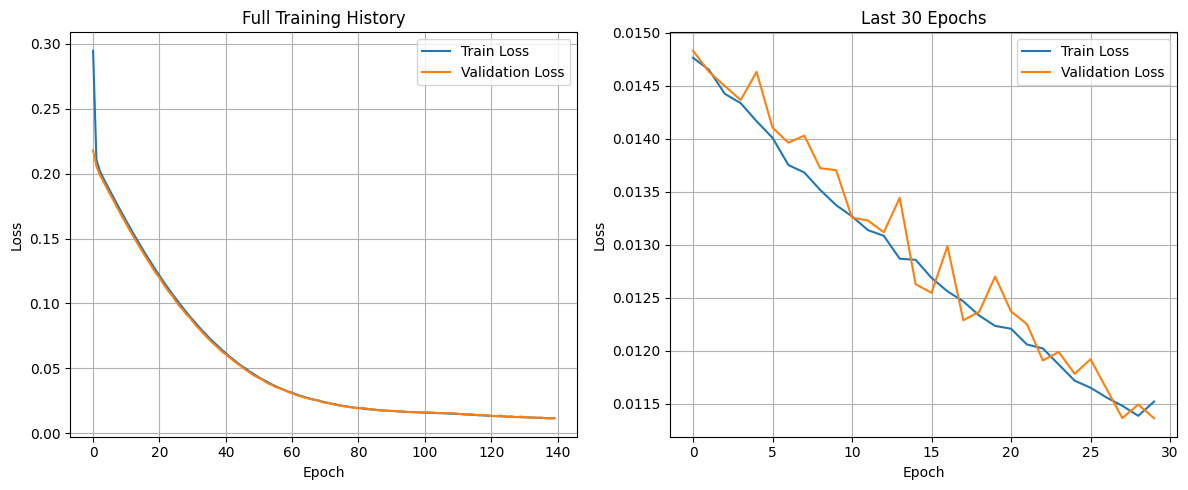

DEBUG: Plot saved and displayed successfully

Training completed in 66.46 minutes
Best validation loss: 0.011364


In [16]:
for variant, latent_dim, bshape, groups in settings:
    print(f"\n=== Training {variant} (latent_dim={latent_dim}, bottleneck_shape={bshape}, groups={groups}) ===")
    cfg = create_training_config(f"{variant}_lat{latent_dim}", num_epochs)
    model = build_model(variant, latent_dim=latent_dim, bottleneck_shape=bshape, basis_groups=groups)
    train_losses, val_losses, trained_model = train_autoencoder(
        model,
        train_loader,
        val_loader,
        config=cfg,
        disable_epoch_bars=True,
        criterion=None,  # default MSE
    )
    histories[variant] = {"train": train_losses, "val": val_losses}